## Kliuev Dmitrii third dz

## Problem 1

Implement serial test and apply to a `samples`

### My solution:

In [1]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = [rng() for _ in range(1000)]

samples_pairs = []
for i in range(0, len(samples) - 1, 2):
    samples_pairs.append((samples[i], samples[i + 1]))

k = 10
x = [pair[0] for pair in samples_pairs]
y = [pair[1] for pair in samples_pairs]

f_obs, x_edges, y_edges = np.histogram2d(x, y, bins=k, range=[[0, 1], [0, 1]])

n_pairs = len(samples_pairs)
f_exp = n_pairs / (k * k)

chi2_stat = np.sum((f_obs - f_exp) ** 2 / f_exp)

df = k * k - 1
p_value = stats.chi2.sf(chi2_stat, df)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", df)
print("p-value:", p_value)

if p_value < 0.05:
    print("Гипотеза о равномерности отвергается")
else:
    print("Нет оснований отвергать гипотезу о равномерности")

Chi-square statistic: 114.39999999999999
Degrees of freedom: 99
p-value: 0.1380441495447643
Нет оснований отвергать гипотезу о равномерности


## Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

### My solution:

In [2]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

samples = [rng_bad() for _ in range(30000)]
samples_uniform = np.random.uniform(0, 1, 30000)
samples_triples = []
for i in range(0, len(samples) - 2, 1):
    samples_triples.append((samples[i], samples[i + 1], samples[i+2]))

k = 10
x = [pair[0] for pair in samples_triples]
y = [pair[1] for pair in samples_triples]
z = [pair[2] for pair in samples_triples]

f_obs, edges = np.histogramdd((x, y, z), bins=k, range=[[0, 1], [0, 1],[0,1]])

n_pairs = len(samples_triples)
f_exp = n_pairs / (k * k * k)

chi2_stat = np.sum((f_obs - f_exp) ** 2 / f_exp)

df = k * k * k - 1
p_value = stats.chi2.sf(chi2_stat, df)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", df)
print("p-value:", p_value)

if p_value < 0.05:
    print("Гипотеза о равномерности отвергается")
else:
    print("Нет оснований отвергать гипотезу о равномерности")

Chi-square statistic: 1241.5493032868858
Degrees of freedom: 999
p-value: 2.151016832918921e-07
Гипотеза о равномерности отвергается


## Problem 4

Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

### My solution:

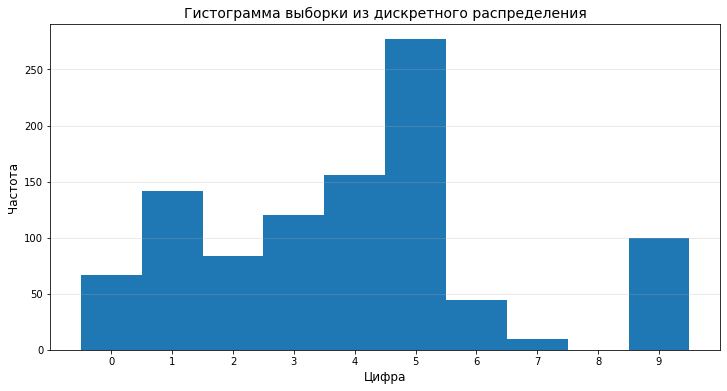

In [3]:
import matplotlib.pyplot as plt

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
values = np.arange(10)

probs = weights / weights.sum()
cdf = np.cumsum(probs)

sample = []
for _ in range(1000):
    u = np.random.uniform(0, 1)
    for i in range(len(cdf)):
        if u < cdf[i]:
            sample.append(values[i])
            break

plt.figure(figsize=(12, 6))
plt.hist(sample, bins=np.arange(-0.5, 10.5, 1))

plt.xlabel('Цифра', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Гистограмма выборки из дискретного распределения', fontsize=14)
plt.xticks(values)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Problem 5

Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

### My solution:

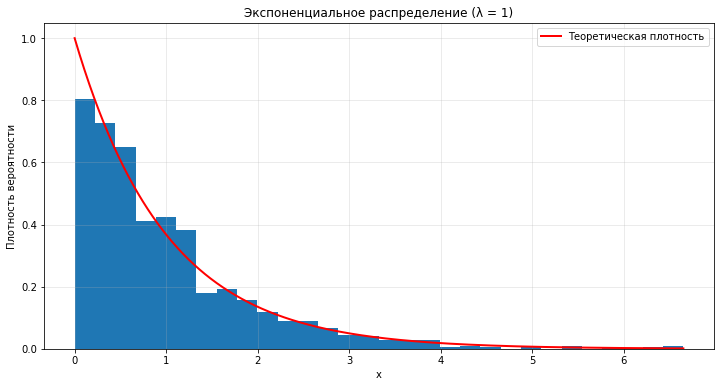

In [4]:
samples_uniform = np.random.uniform(0, 1, 1000)
L = 1

samples_exp = []
for u in samples_uniform:
    x = -np.log(1 - u) / L
    samples_exp.append(x)


plt.figure(figsize=(12, 6))


plt.hist(samples_exp, bins=30, density=True)

x = np.linspace(0, max(samples_exp), 1000)
y = L * np.exp(-L * x)
plt.plot(x, y, 'r-', linewidth=2, label='Теоретическая плотность')

plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.title('Экспоненциальное распределение (λ = 1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Problem 6

Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

### My solution:

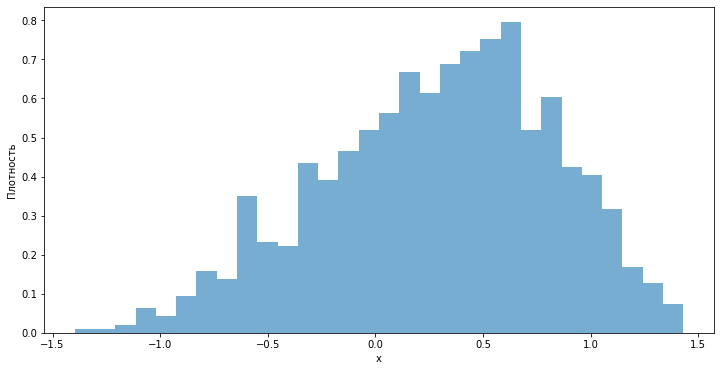

In [5]:
def f(x):
    return np.exp(x) * np.cos(x)**2

grid = np.linspace(-np.pi/2, np.pi/2, 10000)
M = np.max(f(grid))

samples = []

while len(samples) < 1000:
    x = np.random.uniform(-np.pi/2, np.pi/2)
    y = np.random.uniform(0, M)
    
    if y <= f(x):
        samples.append(x)

plt.figure(figsize=(12, 6))        
plt.hist(samples, bins=30, density=True, alpha=0.6)
plt.xlabel('x')
plt.ylabel('Плотность')
plt.show()

## Problem 7

Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

### My solution:

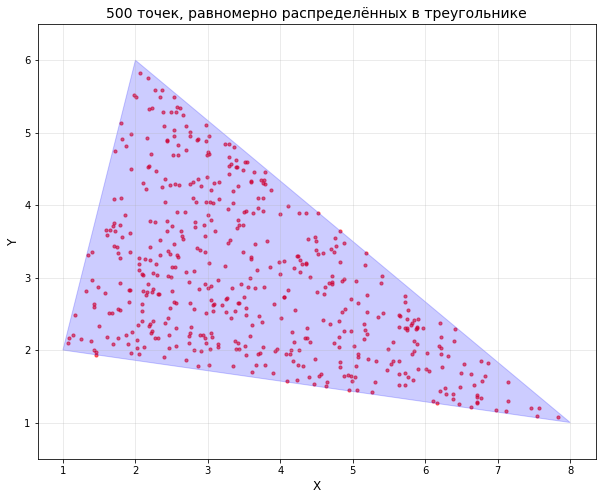

In [6]:
A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

points = []

for _ in range(500):
    u = np.random.rand()
    v = np.random.rand()

    if u + v > 1:
        u = 1 - u
        v = 1 - v

    P = A + u * (B - A) + v * (C - A)
    points.append(P)

points = np.array(points)

plt.figure(figsize=(10, 8))

plt.fill([A[0], B[0], C[0]], [A[1], B[1], C[1]], alpha=0.2, color='blue')

plt.scatter(points[:, 0], points[:, 1], s=10, color='red', alpha=0.6)

plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('500 точек, равномерно распределённых в треугольнике', fontsize=14)

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## Problem 8

Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

### My solution:

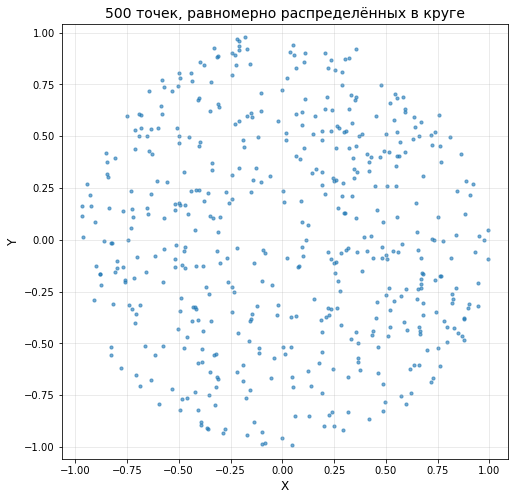

In [7]:
n = 500

phi = np.random.uniform(0, 2*np.pi, n)
r = np.sqrt(np.random.uniform(0, 1, n))

x = r * np.cos(phi)
y = r * np.sin(phi)

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=10, alpha=0.6)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('500 точек, равномерно распределённых в круге', fontsize=14)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## Problem 9

Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

### My solution:

Точное среднее:
[4 7]

Выборочное среднее:
[3.99366971 6.91653382]

Точная ковариационная матрица:
[[20 -4]
 [-4 40]]

Выборочная ковариационная матрица:
[[20.19512751 -3.44572348]
 [-3.44572348 38.76598954]]


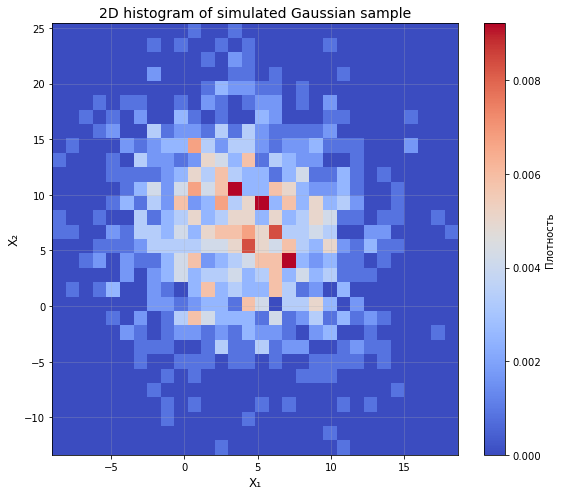

In [8]:
mu = np.array([4, 7])
Sigma = np.array([[20, -4],
                  [-4, 40]])

n = 1000

z1_list = []
z2_list = []

while len(z1_list) < n:
    u = np.random.uniform(-1, 1)
    v = np.random.uniform(-1, 1)
    s = u**2 + v**2

    if s == 0 or s >= 1:
        continue
    z1_list.append(u * np.sqrt(-2 * np.log(s) / s))
    z2_list.append(v * np.sqrt(-2 * np.log(s) / s))

Z = np.vstack((z1_list, z2_list)) 

A = np.linalg.cholesky(Sigma)
X = (A @ Z).T + mu 

sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)

print("Точное среднее:")
print(mu)
print("\nВыборочное среднее:")
print(sample_mean)

print("\nТочная ковариационная матрица:")
print(Sigma)
print("\nВыборочная ковариационная матрица:")
print(sample_cov)

plt.figure(figsize=(8, 7))
plt.hist2d(X[:, 0], X[:, 1], bins=30, density=True, cmap='coolwarm')
plt.colorbar(label='Плотность')
plt.xlabel('X₁', fontsize=12)
plt.ylabel('X₂', fontsize=12)
plt.title('2D histogram of simulated Gaussian sample', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()